# Week 3 — Statistical Analysis and Hypothesis Testing in Python

**Research question:** Do mean petal lengths differ among Iris species?

**H0:** Mean petal length is equal across species.

**H1:** At least one species has a different mean petal length.

Alpha = 0.05. Welch ANOVA is the primary omnibus test because the variance-homogeneity check indicates unequal variances.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

sns.set_theme(style='whitegrid')


In [2]:
df = pd.read_csv('../data/processed/iris_cleaned_week3.csv')
print(df.shape)
display(df.head())
display(df.groupby('species').size())

(149, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


species
setosa        50
versicolor    50
virginica     49
dtype: int64

## 1. Descriptive statistics
Descriptive statistics establish the observed group differences before formal testing.

In [3]:
summary = df.groupby('species')['petal_length'].agg(['count','mean','std','median','min','max'])
display(summary)

,count,mean,std,median,min,max
species,,,,,,
setosa,50,1.462000,0.173664,1.5,1.0,1.9
versicolor,50,4.258000,0.469516,4.3,3.0,5.1
virginica,49,5.561224,0.553706,5.6,4.5,6.9


## 2. Assumption checks
We examine residual normality and homogeneity of variance. These checks inform whether classical ANOVA assumptions are reasonable and whether a robust alternative should be emphasized.

In [4]:
model = ols('petal_length ~ C(species)', data=df).fit()
groups = [df.loc[df.species==s,'petal_length'] for s in ['setosa','versicolor','virginica']]
print('Shapiro-Wilk residual test:', stats.shapiro(model.resid))
print('Levene variance test:', stats.levene(*groups, center='median'))

Shapiro-Wilk residual test: ShapiroResult(statistic=np.float64(0.979911825748804), pvalue=np.float64(0.027994297333641133))
Levene variance test: LeveneResult(statistic=np.float64(19.32215105128643), pvalue=np.float64(3.591178673280214e-08))


## 3. Omnibus hypothesis tests
The classical ANOVA is shown for completeness. Welch ANOVA is the primary test because the variance-homogeneity assumption is not supported. Kruskal-Wallis provides a non-parametric sensitivity analysis.

In [5]:
classic = stats.f_oneway(*groups)
welch = stats.f_oneway(*groups, equal_var=False)
kruskal = stats.kruskal(*groups)
print('Classical ANOVA:', classic)
print('Welch ANOVA:', welch)
print('Kruskal-Wallis:', kruskal)

Classical ANOVA: F_onewayResult(statistic=np.float64(1177.3598215426439), pvalue=np.float64(8.68986583755638e-91))
Welch ANOVA: F_onewayResult(statistic=np.float64(1807.2161468199079), pvalue=np.float64(1.5797374929680398e-65))
Kruskal-Wallis: KruskalResult(statistic=np.float64(129.5330455401419), pvalue=np.float64(7.45172036162183e-29))


## 4. Effect size and confidence intervals
Eta-squared summarizes the proportion of observed variance associated with species in the classical ANOVA framework. Confidence intervals describe uncertainty around each group mean.

In [6]:
anova = sm.stats.anova_lm(model, typ=2)
ssb = anova.loc['C(species)','sum_sq']; sse = anova.loc['Residual','sum_sq']; sst = ssb+sse
eta_sq = ssb/sst
msw = sse/anova.loc['Residual','df']
omega_sq = (ssb-anova.loc['C(species)','df']*msw)/(sst+msw)
print('Eta squared:', eta_sq)
print('Omega squared:', omega_sq)
for s in ['setosa','versicolor','virginica']:
    x=df.loc[df.species==s,'petal_length']
    ci=stats.t.interval(.95,len(x)-1,loc=x.mean(),scale=stats.sem(x))
    print(s, 'mean=', x.mean(), '95% CI=', ci)

Eta squared: 0.9416168060247366
Omega squared: 0.9404409681109418
setosa mean= 1.4620000000000002 95% CI= (np.float64(1.4126452382875103), np.float64(1.51135476171249))
versicolor mean= 4.258 95% CI= (np.float64(4.124565143080875), np.float64(4.391434856919125))
virginica mean= 5.5612244897959195 95% CI= (np.float64(5.402181608521592), np.float64(5.720267371070247))


## 5. Pairwise follow-up tests
Welch two-sample t-tests compare species pairs without assuming equal variances. Holm adjustment controls family-wise error across the three comparisons.

In [7]:
from statsmodels.stats.multitest import multipletests
pairs=[('setosa','versicolor'),('setosa','virginica'),('versicolor','virginica')]
raw=[]
for a,b in pairs:
    t,p=stats.ttest_ind(df.loc[df.species==a,'petal_length'],df.loc[df.species==b,'petal_length'],equal_var=False)
    raw.append(p)
    print(a,b,'t=',t,'p=',p)
print('Holm-adjusted p-values:', multipletests(raw, method='holm')[1])

setosa versicolor t= -39.493725124949776 p= 9.677405081072915e-46
setosa virginica t= -49.49207711416378 p= 1.218170990191342e-48
versicolor virginica t= -12.61890614453467 p= 6.260719958553715e-22
Holm-adjusted p-values: [1.93548102e-45 3.65451297e-48 6.26071996e-22]


## 6. Visualization: distribution
The violin/box plot shows within-species distributions, central tendency, spread, and overlap.

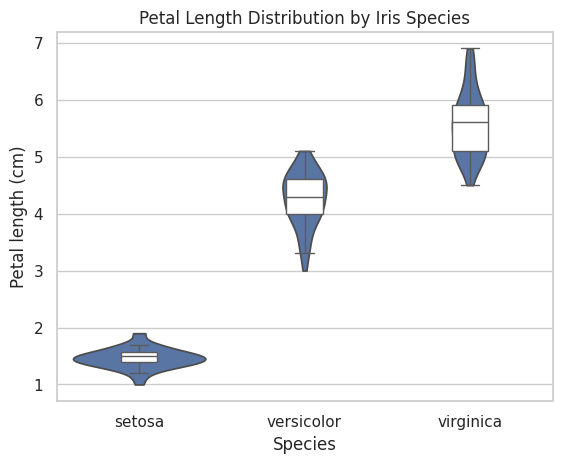

In [8]:
sns.violinplot(data=df,x='species',y='petal_length',order=['setosa','versicolor','virginica'],inner=None,cut=0)
sns.boxplot(data=df,x='species',y='petal_length',order=['setosa','versicolor','virginica'],width=.22,showfliers=False,boxprops={'facecolor':'white'})
plt.title('Petal Length Distribution by Iris Species'); plt.xlabel('Species'); plt.ylabel('Petal length (cm)'); plt.show()

## 7. Visualization: means and confidence intervals

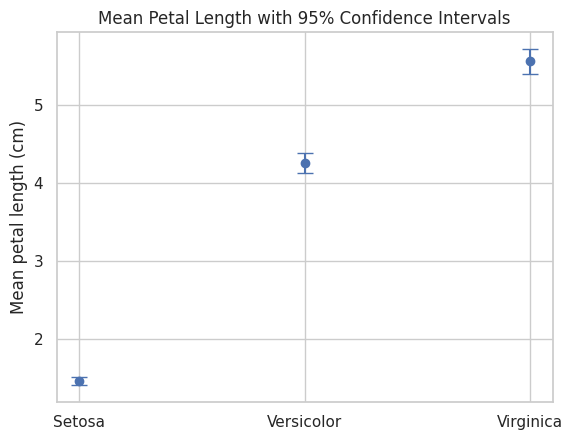

In [9]:
means=df.groupby('species')['petal_length'].mean().reindex(['setosa','versicolor','virginica'])
ci_low=[]; ci_high=[]
for s in means.index:
    x=df.loc[df.species==s,'petal_length']; ci=stats.t.interval(.95,len(x)-1,loc=x.mean(),scale=stats.sem(x)); ci_low.append(ci[0]); ci_high.append(ci[1])
x=np.arange(3); plt.errorbar(x,means,yerr=[means-np.array(ci_low),np.array(ci_high)-means],fmt='o',capsize=6)
plt.xticks(x,['Setosa','Versicolor','Virginica']); plt.ylabel('Mean petal length (cm)'); plt.title('Mean Petal Length with 95% Confidence Intervals'); plt.show()

## 8. Visualization: residual diagnostics

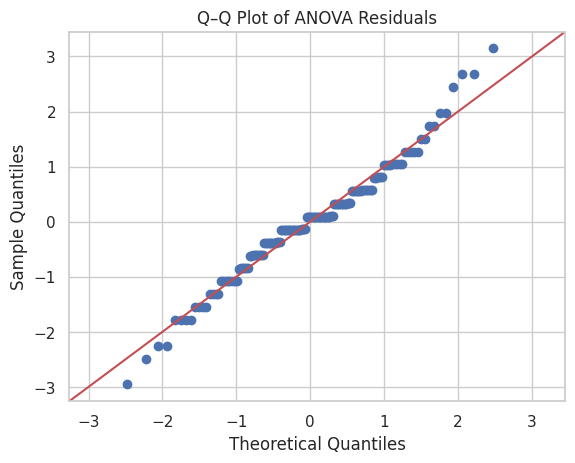

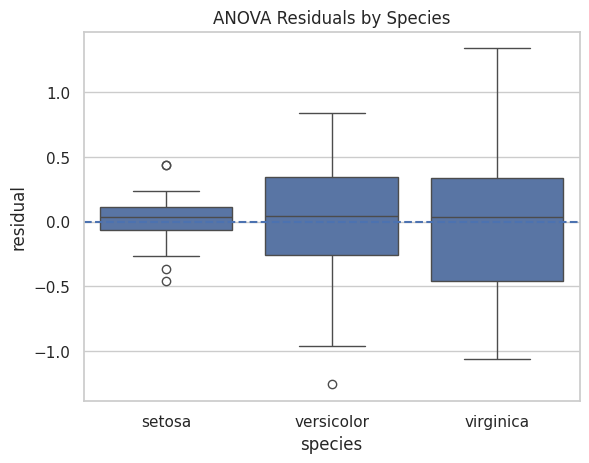

In [10]:
sm.qqplot(model.resid,line='45',fit=True); plt.title('Q–Q Plot of ANOVA Residuals'); plt.show()
resdf=df.copy(); resdf['residual']=model.resid
sns.boxplot(data=resdf,x='species',y='residual',order=['setosa','versicolor','virginica']); plt.axhline(0,ls='--'); plt.title('ANOVA Residuals by Species'); plt.show()

## 9. Conclusion
At alpha = 0.05, the omnibus evidence is sufficient to reject H0 for this dataset. The robust Welch ANOVA and Kruskal-Wallis analysis agree, and all three pairwise Welch comparisons remain significant after Holm correction. The result supports a species-associated difference in mean petal length in this Iris sample. Statistical significance should not be interpreted as proof of causation or universal generalization beyond the dataset.